# Modeling — Churn Prediction

Implementación completa siguiendo el plan de `modeling.md`.  
Dataset: `data/warehouse/train.csv` — 58.049 filas, 22 features + target `churn` (8.8% positivos).

Modelos entrenados: **Logistic Regression · Random Forest · XGBoost · LightGBM**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Carga del dataset

In [2]:
df = pd.read_csv("data/warehouse/train.csv")

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['churn'].mean():.1%}")
print(f"Positivos: {df['churn'].sum():,}  |  Negativos: {(df['churn']==0).sum():,}")
df.head(3)

Shape: (58049, 23)
Churn rate: 8.8%
Positivos: 5,093  |  Negativos: 52,956


,pvp,margen_relativo,margen_eur_negativo,coste_venta_no_impuestos,forma_pago,dias_desde_compra,en_garantia,mantenimiento_gratuito,seguro_bateria_largo_plazo,ext_garantia_tiene,...,edad,genero,renta_media_estimada,renta_desconocida,status_social,modelo,equipamiento,es_electrico,kw,churn
0,18579.0,0.085946,0,1529.0,Contado,363,1,0,0,0,...,47,M,25641.0,0,H,B,Low,0,74.0,0
1,15195.0,0.068886,0,864.0,Otros,1621,0,0,0,0,...,36,F,0.0,1,Sin_dato,A,High,0,64.0,0
2,30330.0,0.218366,0,1034.0,Otros,628,1,0,0,0,...,39,M,0.0,1,Sin_dato,I,Mid,0,106.0,0


## Distribuciones: churn vs no churn

Análisis visual de las features más discriminantes antes de entrenar los modelos.  
Línea roja discontinua = tasa de churn global (8.8%).

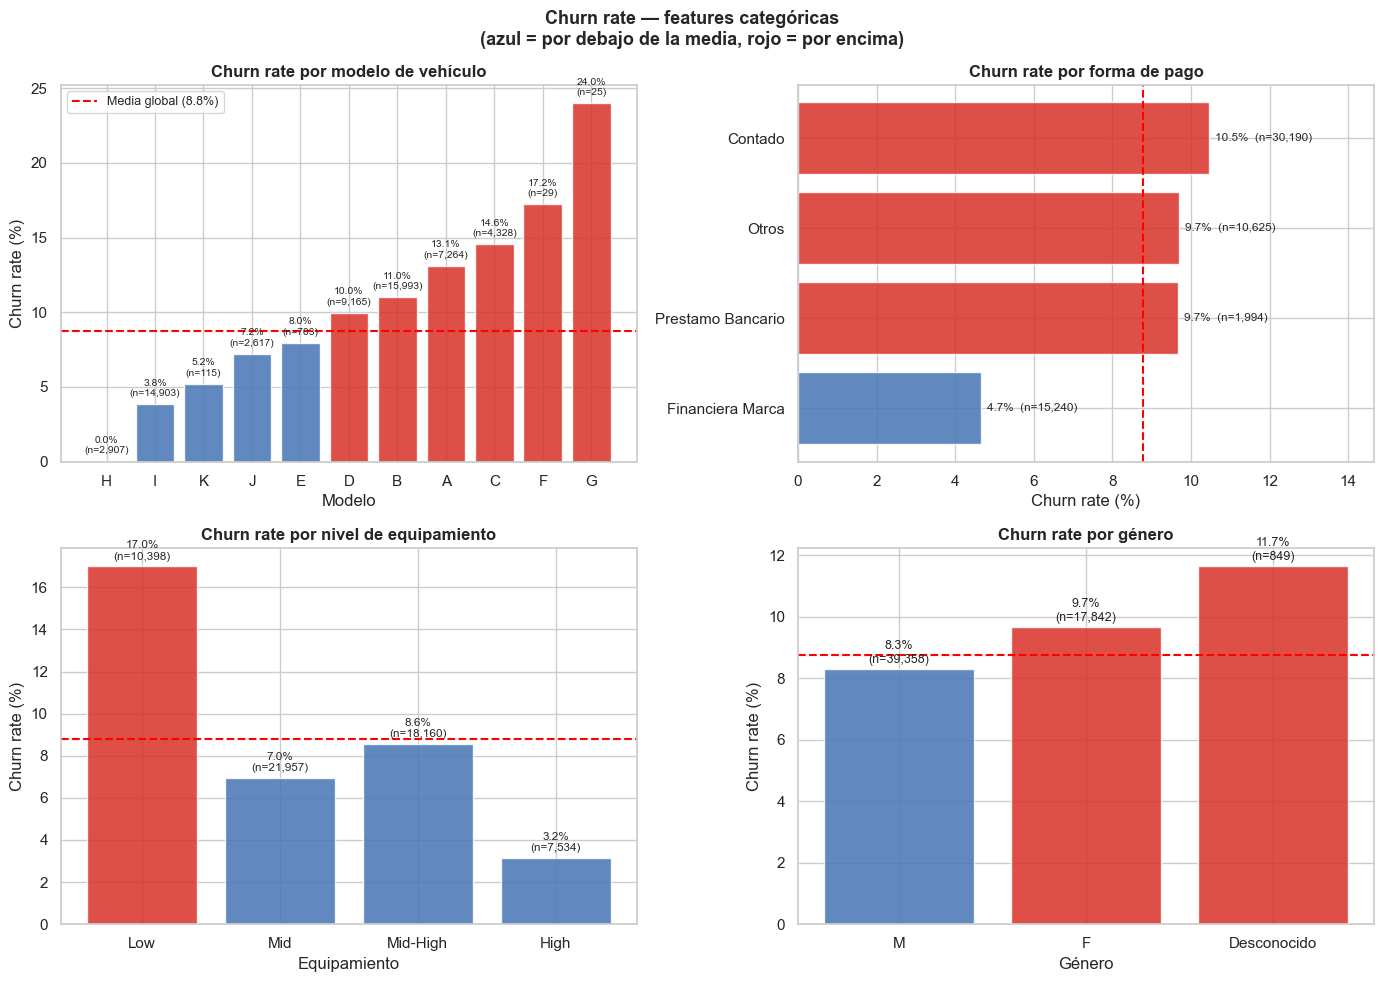

In [3]:
# ── Features categóricas ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
global_rate = df['churn'].mean() * 100

# modelo
ax = axes[0, 0]
cr = df.groupby('modelo')['churn'].agg(['mean', 'count']).sort_values('mean')
colors_bar = ['#d73027' if v > df['churn'].mean() else '#4575b4' for v in cr['mean']]
bars = ax.bar(cr.index, cr['mean'] * 100, color=colors_bar, alpha=0.85, edgecolor='white')
ax.axhline(global_rate, color='red', linestyle='--', linewidth=1.5, label=f'Media global ({global_rate:.1f}%)')
for bar, (_, row) in zip(bars, cr.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{row["mean"]:.1%}\n(n={int(row["count"]):,})', ha='center', va='bottom', fontsize=7.5)
ax.set_title('Churn rate por modelo de vehículo', fontweight='bold')
ax.set_xlabel('Modelo'); ax.set_ylabel('Churn rate (%)')
ax.legend(fontsize=9)

# forma_pago
ax = axes[0, 1]
cr = df.groupby('forma_pago')['churn'].agg(['mean', 'count']).sort_values('mean')
colors_bar = ['#d73027' if v > df['churn'].mean() else '#4575b4' for v in cr['mean']]
bars = ax.barh(cr.index, cr['mean'] * 100, color=colors_bar, alpha=0.85, edgecolor='white')
ax.axvline(global_rate, color='red', linestyle='--', linewidth=1.5)
for bar, (_, row) in zip(bars, cr.iterrows()):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            f'{row["mean"]:.1%}  (n={int(row["count"]):,})', va='center', fontsize=8.5)
ax.set_xlim(0, cr['mean'].max() * 100 * 1.4)
ax.set_title('Churn rate por forma de pago', fontweight='bold')
ax.set_xlabel('Churn rate (%)')

# equipamiento
ax = axes[1, 0]
eq_order = ['Low', 'Mid', 'Mid-High', 'High']
cr = df.groupby('equipamiento')['churn'].agg(['mean', 'count']).reindex(eq_order)
colors_bar = ['#d73027' if v > df['churn'].mean() else '#4575b4' for v in cr['mean']]
bars = ax.bar(cr.index, cr['mean'] * 100, color=colors_bar, alpha=0.85, edgecolor='white')
ax.axhline(global_rate, color='red', linestyle='--', linewidth=1.5)
for bar, (_, row) in zip(bars, cr.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{row["mean"]:.1%}\n(n={int(row["count"]):,})', ha='center', va='bottom', fontsize=8.5)
ax.set_title('Churn rate por nivel de equipamiento', fontweight='bold')
ax.set_xlabel('Equipamiento'); ax.set_ylabel('Churn rate (%)')

# genero
ax = axes[1, 1]
cr = df.groupby('genero')['churn'].agg(['mean', 'count']).sort_values('mean')
colors_bar = ['#d73027' if v > df['churn'].mean() else '#4575b4' for v in cr['mean']]
bars = ax.bar(cr.index, cr['mean'] * 100, color=colors_bar, alpha=0.85, edgecolor='white')
ax.axhline(global_rate, color='red', linestyle='--', linewidth=1.5)
for bar, (_, row) in zip(bars, cr.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{row["mean"]:.1%}\n(n={int(row["count"]):,})', ha='center', va='bottom', fontsize=9)
ax.set_title('Churn rate por género', fontweight='bold')
ax.set_xlabel('Género'); ax.set_ylabel('Churn rate (%)')

plt.suptitle('Churn rate — features categóricas\n(azul = por debajo de la media, rojo = por encima)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

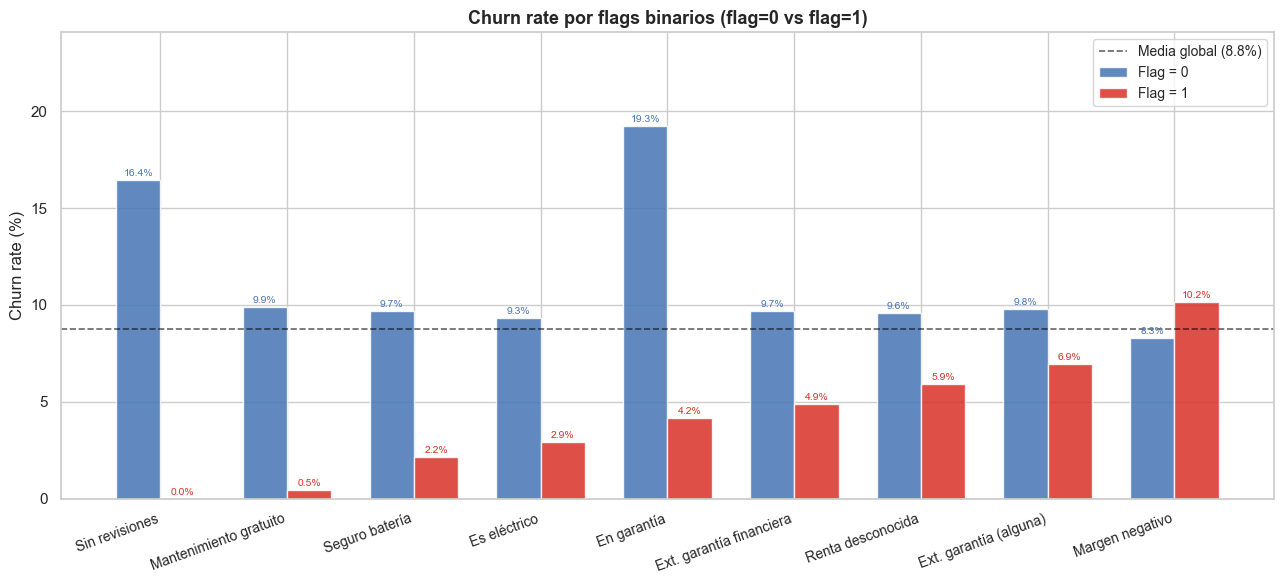

In [4]:
# ── Flags binarios: churn rate cuando flag=1 vs flag=0 ───────────────────────
flag_meta = {
    'en_garantia':              'En garantía',
    'mantenimiento_gratuito':   'Mantenimiento gratuito',
    'seguro_bateria_largo_plazo': 'Seguro batería',
    'ext_garantia_financiera':  'Ext. garantía financiera',
    'ext_garantia_tiene':       'Ext. garantía (alguna)',
    'es_electrico':             'Es eléctrico',
    'sin_revisiones':           'Sin revisiones',
    'renta_desconocida':        'Renta desconocida',
    'margen_eur_negativo':      'Margen negativo',
}

global_rate = df['churn'].mean()

rows = []
for col, label in flag_meta.items():
    cr1 = df.loc[df[col] == 1, 'churn'].mean()
    cr0 = df.loc[df[col] == 0, 'churn'].mean()
    n1  = (df[col] == 1).sum()
    rows.append({'label': label, 'flag=1': cr1, 'flag=0': cr0, 'n_flag1': n1})

flag_df = pd.DataFrame(rows).sort_values('flag=1')

x = np.arange(len(flag_df))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - w/2, flag_df['flag=0'] * 100, w, label='Flag = 0', color='#4575b4', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, flag_df['flag=1'] * 100, w, label='Flag = 1', color='#d73027', alpha=0.85, edgecolor='white')

ax.axhline(global_rate * 100, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label=f'Media global ({global_rate:.1%})')

# Value labels
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7.5, color='#4575b4')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7.5, color='#d73027')

ax.set_xticks(x)
ax.set_xticklabels(flag_df['label'], rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn rate por flags binarios (flag=0 vs flag=1)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, flag_df[['flag=0','flag=1']].max().max() * 100 * 1.25)

plt.tight_layout()
plt.show()

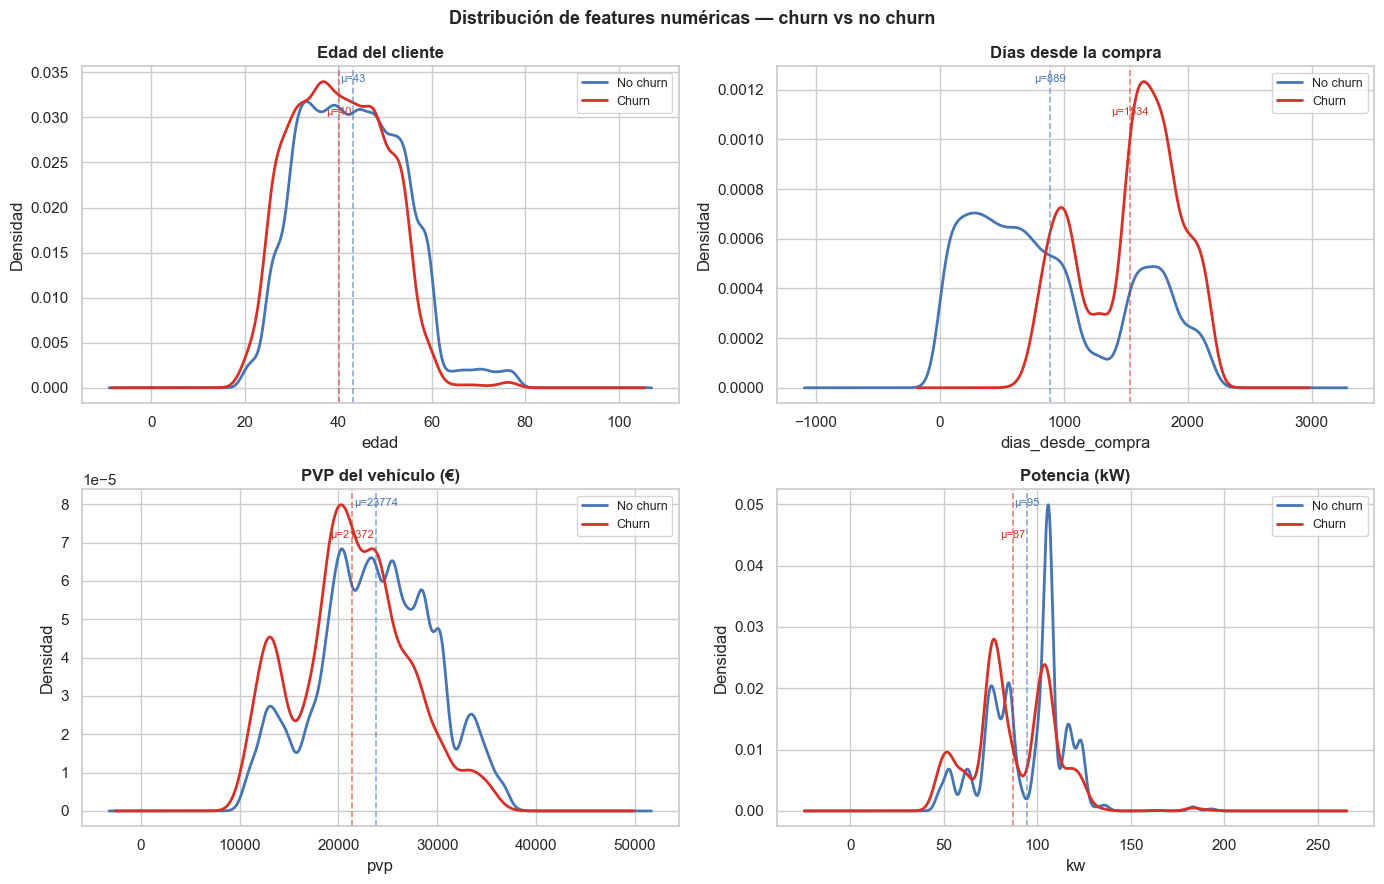

In [5]:
# ── Distribuciones numéricas: churn vs no churn ──────────────────────────────
num_plot = {
    'edad':                 'Edad del cliente',
    'dias_desde_compra':    'Días desde la compra',
    'pvp':                  'PVP del vehículo (€)',
    'kw':                   'Potencia (kW)',
}

churn0 = df[df['churn'] == 0]
churn1 = df[df['churn'] == 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (col, title) in zip(axes.flat, num_plot.items()):
    # KDE
    churn0[col].plot.kde(ax=ax, label='No churn', color='#4575b4', linewidth=2)
    churn1[col].plot.kde(ax=ax, label='Churn',    color='#d73027', linewidth=2)
    
    # Vertical means
    ax.axvline(churn0[col].mean(), color='#4575b4', linestyle='--', alpha=0.6, linewidth=1.2)
    ax.axvline(churn1[col].mean(), color='#d73027', linestyle='--', alpha=0.6, linewidth=1.2)
    
    # Annotations
    ax.text(churn0[col].mean(), ax.get_ylim()[1] * 0.95,
            f'μ={churn0[col].mean():.0f}', color='#4575b4', ha='center', fontsize=8)
    ax.text(churn1[col].mean(), ax.get_ylim()[1] * 0.85,
            f'μ={churn1[col].mean():.0f}', color='#d73027', ha='center', fontsize=8)
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features numéricas — churn vs no churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

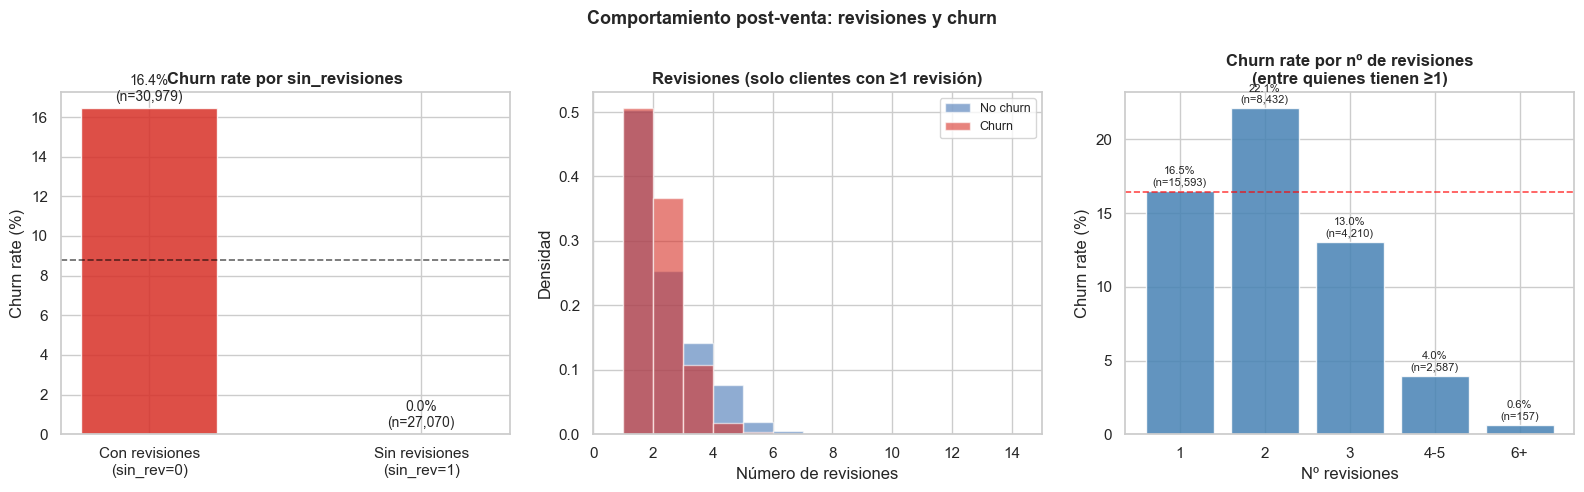

In [6]:
# ── Revisiones: sin_revisiones + distribución entre los que SÍ tienen ────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Churn rate: sin_revisiones
ax = axes[0]
cr_rev = df.groupby('sin_revisiones')['churn'].agg(['mean', 'count'])
labels = ['Con revisiones\n(sin_rev=0)', 'Sin revisiones\n(sin_rev=1)']
colors_bar = ['#d73027' if v > df['churn'].mean() else '#4575b4' for v in cr_rev['mean']]
bars = ax.bar(labels, cr_rev['mean'] * 100, color=colors_bar, alpha=0.85, edgecolor='white', width=0.5)
ax.axhline(df['churn'].mean() * 100, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
for bar, (_, row) in zip(bars, cr_rev.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{row["mean"]:.1%}\n(n={int(row["count"]):,})', ha='center', va='bottom', fontsize=10)
ax.set_title('Churn rate por sin_revisiones', fontweight='bold')
ax.set_ylabel('Churn rate (%)')

# 2. Distribución de número de revisiones (solo clientes con revisiones > 0)
ax = axes[1]
has_rev = df[df['sin_revisiones'] == 0]
bins = range(0, int(has_rev['revisiones'].max()) + 2)
ax.hist(has_rev.loc[has_rev['churn']==0, 'revisiones'],
        bins=bins, density=True, alpha=0.6, color='#4575b4', label='No churn', edgecolor='white')
ax.hist(has_rev.loc[has_rev['churn']==1, 'revisiones'],
        bins=bins, density=True, alpha=0.6, color='#d73027', label='Churn',    edgecolor='white')
ax.set_title('Revisiones (solo clientes con ≥1 revisión)', fontweight='bold')
ax.set_xlabel('Número de revisiones'); ax.set_ylabel('Densidad')
ax.legend(fontsize=9)
ax.set_xlim(0, 15)

# 3. Churn rate por número de revisiones (buckets)
ax = axes[2]
has_rev2 = df[df['sin_revisiones'] == 0].copy()
has_rev2['rev_bucket'] = pd.cut(has_rev2['revisiones'],
                                 bins=[0, 1, 2, 3, 5, 100],
                                 labels=['1', '2', '3', '4-5', '6+'],
                                 right=True)
cr_b = has_rev2.groupby('rev_bucket', observed=True)['churn'].agg(['mean','count'])
bars = ax.bar(cr_b.index.astype(str), cr_b['mean'] * 100,
              color='steelblue', alpha=0.85, edgecolor='white')
ax.axhline(has_rev2['churn'].mean() * 100, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
for bar, (_, row) in zip(bars, cr_b.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{row["mean"]:.1%}\n(n={int(row["count"]):,})', ha='center', va='bottom', fontsize=8)
ax.set_title('Churn rate por nº de revisiones\n(entre quienes tienen ≥1)', fontweight='bold')
ax.set_xlabel('Nº revisiones'); ax.set_ylabel('Churn rate (%)')

plt.suptitle('Comportamiento post-venta: revisiones y churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Split train / test

- 80% train / 20% test, estratificado por `churn`
- Split **antes** de cualquier preprocessing para evitar data leakage

In [7]:
X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}  |  Positivos: {y_train.sum()} ({y_train.mean():.1%})")
print(f"Test:  {X_test.shape}   |  Positivos: {y_test.sum()} ({y_test.mean():.1%})")

scale_pos_weight = float((y_train == 0).sum() / y_train.sum())
print(f"\nscale_pos_weight (para XGBoost): {scale_pos_weight:.2f}")

Train: (46439, 22)  |  Positivos: 4074 (8.8%)
Test:  (11610, 22)   |  Positivos: 1019 (8.8%)

scale_pos_weight (para XGBoost): 10.40


## 3. Grupos de features

| Tipo | Features |
|---|---|
| **Numéricas** | pvp, margen_relativo, coste_venta_no_impuestos, dias_desde_compra, revisiones, edad, renta_media_estimada, kw |
| **Categóricas (OHE)** | forma_pago, genero |
| **Categóricas (ordinal)** | equipamiento |
| **Categóricas (muchas clases → OHE)** | status_social, modelo |
| **Flags binarios (pass-through)** | margen_eur_negativo, en_garantia, mantenimiento_gratuito, seguro_bateria_largo_plazo, ext_garantia_tiene, ext_garantia_financiera, sin_revisiones, renta_desconocida, es_electrico |

In [8]:
num_features = [
    'pvp', 'margen_relativo', 'coste_venta_no_impuestos',
    'dias_desde_compra', 'revisiones', 'edad', 'renta_media_estimada', 'kw'
]

cat_ohe_features = ['forma_pago', 'genero']

cat_ordinal_features = ['equipamiento']
equipamiento_order = [['Low', 'Mid', 'Mid-High', 'High']]

cat_many_features = ['status_social', 'modelo']  # OHE en LR; OrdinalEncoder en tree models

cat_all_features = cat_ohe_features + cat_ordinal_features + cat_many_features

binary_features = [
    'margen_eur_negativo', 'en_garantia', 'mantenimiento_gratuito',
    'seguro_bateria_largo_plazo', 'ext_garantia_tiene', 'ext_garantia_financiera',
    'sin_revisiones', 'renta_desconocida', 'es_electrico'
]

print(f"Numéricas:      {len(num_features)}")
print(f"Categóricas:    {len(cat_all_features)}")
print(f"Flags binarios: {len(binary_features)}")
print(f"Total features: {len(num_features) + len(cat_all_features) + len(binary_features)}")

Numéricas:      8
Categóricas:    5
Flags binarios: 9
Total features: 22


## 4. Función de evaluación

Calcula ROC-AUC, PR-AUC y el **umbral óptimo** (maximiza F1) en la curva Precision-Recall.

In [9]:
def evaluate_model(name, model, X_te, y_te):
    """Evalúa un modelo. Devuelve dict con métricas y arrays para plotting."""
    y_proba = model.predict_proba(X_te)[:, 1]

    roc_auc = roc_auc_score(y_te, y_proba)
    pr_auc  = average_precision_score(y_te, y_proba)

    # Umbral óptimo: maximiza F1 sobre la curva Precision-Recall
    precision_arr, recall_arr, thresholds = precision_recall_curve(y_te, y_proba)
    f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-8)
    opt_idx       = np.argmax(f1_arr[:-1])
    opt_threshold = float(thresholds[opt_idx])
    opt_f1        = float(f1_arr[opt_idx])

    y_pred = (y_proba >= opt_threshold).astype(int)

    return {
        'model':         name,
        'roc_auc':       roc_auc,
        'pr_auc':        pr_auc,
        'opt_threshold': opt_threshold,
        'f1_opt':        opt_f1,
        'y_proba':       y_proba,
        'y_pred':        y_pred,
    }

results = {}   # se va rellenando con cada modelo
print("evaluate_model definida.")

evaluate_model definida.


## 5. Logistic Regression — baseline interpretable

- `forma_pago`, `genero`, `status_social`, `modelo` → `OneHotEncoder(drop='first')`
- `equipamiento` → `OrdinalEncoder` (Low < Mid < Mid-High < High)
- Numéricas → `StandardScaler`
- Desbalanceo → `class_weight='balanced'`

In [10]:
lr_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                                                        num_features),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
                                                                                     cat_ohe_features + cat_many_features),
    ('ord', OrdinalEncoder(categories=equipamiento_order),                           cat_ordinal_features),
    ('bin', 'passthrough',                                                           binary_features),
], remainder='drop')

lr_pipeline = Pipeline([
    ('prep', lr_preprocessor),
    ('clf',  LogisticRegression(
                 class_weight='balanced',
                 max_iter=2000,
                 random_state=42,
                 C=0.1,
             )),
])

print("Entrenando Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
results['lr'] = evaluate_model('Logistic Regression', lr_pipeline, X_test, y_test)
res = results['lr']
print(f"ROC-AUC: {res['roc_auc']:.4f}  |  PR-AUC: {res['pr_auc']:.4f}  |  F1: {res['f1_opt']:.4f}  (umbral={res['opt_threshold']:.3f})")

Entrenando Logistic Regression...
ROC-AUC: 0.9518  |  PR-AUC: 0.4877  |  F1: 0.6525  (umbral=0.720)


## 6. Random Forest

- Todas las categóricas → `OrdinalEncoder`
- Numéricas → sin escalar (los árboles no lo necesitan)
- Desbalanceo → `class_weight='balanced'`

In [11]:
rf_preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough',                                                                    num_features),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
                                                                              cat_ohe_features + cat_many_features),
    ('ord', OrdinalEncoder(categories=equipamiento_order),                        cat_ordinal_features),
    ('bin', 'passthrough',                                                        binary_features),
], remainder='drop')

rf_pipeline = Pipeline([
    ('prep', rf_preprocessor),
    ('clf',  RandomForestClassifier(
                 n_estimators=300,
                 max_depth=10,
                 min_samples_leaf=10,
                 class_weight='balanced',
                 random_state=42,
                 n_jobs=-1,
             )),
])

print("Entrenando Random Forest...")
rf_pipeline.fit(X_train, y_train)
results['rf'] = evaluate_model('Random Forest', rf_pipeline, X_test, y_test)
res = results['rf']
print(f"ROC-AUC: {res['roc_auc']:.4f}  |  PR-AUC: {res['pr_auc']:.4f}  |  F1: {res['f1_opt']:.4f}  (umbral={res['opt_threshold']:.3f})")

Entrenando Random Forest...
ROC-AUC: 0.9585  |  PR-AUC: 0.6345  |  F1: 0.6455  (umbral=0.768)


## 7. XGBoost

- Todas las categóricas → `OrdinalEncoder`
- Numéricas → sin escalar
- Desbalanceo → `scale_pos_weight = n_negativos / n_positivos`

In [12]:
xgb_preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough',                                                                    num_features),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
                                                                              cat_ohe_features + cat_many_features),
    ('ord', OrdinalEncoder(categories=equipamiento_order),                        cat_ordinal_features),
    ('bin', 'passthrough',                                                        binary_features),
], remainder='drop')

xgb_pipeline = Pipeline([
    ('prep', xgb_preprocessor),
    ('clf',  XGBClassifier(
                 scale_pos_weight=scale_pos_weight,
                 n_estimators=300,
                 max_depth=6,
                 learning_rate=0.05,
                 subsample=0.8,
                 colsample_bytree=0.8,
                 random_state=42,
                 n_jobs=-1,
                 eval_metric='logloss',
                 verbosity=0,
             )),
])

print("Entrenando XGBoost...")
xgb_pipeline.fit(X_train, y_train)
results['xgb'] = evaluate_model('XGBoost', xgb_pipeline, X_test, y_test)
res = results['xgb']
print(f"ROC-AUC: {res['roc_auc']:.4f}  |  PR-AUC: {res['pr_auc']:.4f}  |  F1: {res['f1_opt']:.4f}  (umbral={res['opt_threshold']:.3f})")

Entrenando XGBoost...
ROC-AUC: 0.9717  |  PR-AUC: 0.7396  |  F1: 0.7023  (umbral=0.851)


## 8. LightGBM

- Categóricas → `category` dtype (soporte nativo en LightGBM)
- Numéricas → sin escalar
- Desbalanceo → `is_unbalance=True`

In [13]:
def prep_lgbm(X):
    """Convierte columnas categóricas a dtype 'category' para LightGBM."""
    X_out = X.copy()
    for col in cat_all_features:
        X_out[col] = X_out[col].astype('category')
    return X_out

X_train_lgbm = prep_lgbm(X_train)
X_test_lgbm  = prep_lgbm(X_test)

lgbm_model = LGBMClassifier(
    is_unbalance=True,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

print("Entrenando LightGBM...")
lgbm_model.fit(X_train_lgbm, y_train)
results['lgbm'] = evaluate_model('LightGBM', lgbm_model, X_test_lgbm, y_test)
res = results['lgbm']
print(f"ROC-AUC: {res['roc_auc']:.4f}  |  PR-AUC: {res['pr_auc']:.4f}  |  F1: {res['f1_opt']:.4f}  (umbral={res['opt_threshold']:.3f})")

Entrenando LightGBM...
ROC-AUC: 0.9711  |  PR-AUC: 0.7271  |  F1: 0.6987  (umbral=0.807)


## 9. Comparación de modelos

In [14]:
summary = pd.DataFrame([
    {
        'Modelo':               v['model'],
        'ROC-AUC':              round(v['roc_auc'], 4),
        'PR-AUC':               round(v['pr_auc'],  4),
        'F1 (umbral óptimo)':   round(v['f1_opt'],  4),
        'Umbral óptimo':        round(v['opt_threshold'], 3),
    }
    for v in results.values()
]).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

summary.style \
    .format({'ROC-AUC': '{:.4f}', 'PR-AUC': '{:.4f}',
             'F1 (umbral óptimo)': '{:.4f}', 'Umbral óptimo': '{:.3f}'}) \
    .highlight_max(subset=['ROC-AUC', 'PR-AUC', 'F1 (umbral óptimo)'], color='#c6efce')

,Modelo,ROC-AUC,PR-AUC,F1 (umbral óptimo),Umbral óptimo
0,XGBoost,0.9717,0.7396,0.7023,0.851
1,LightGBM,0.9711,0.7271,0.6987,0.807
2,Random Forest,0.9585,0.6345,0.6455,0.768
3,Logistic Regression,0.9518,0.4877,0.6525,0.720


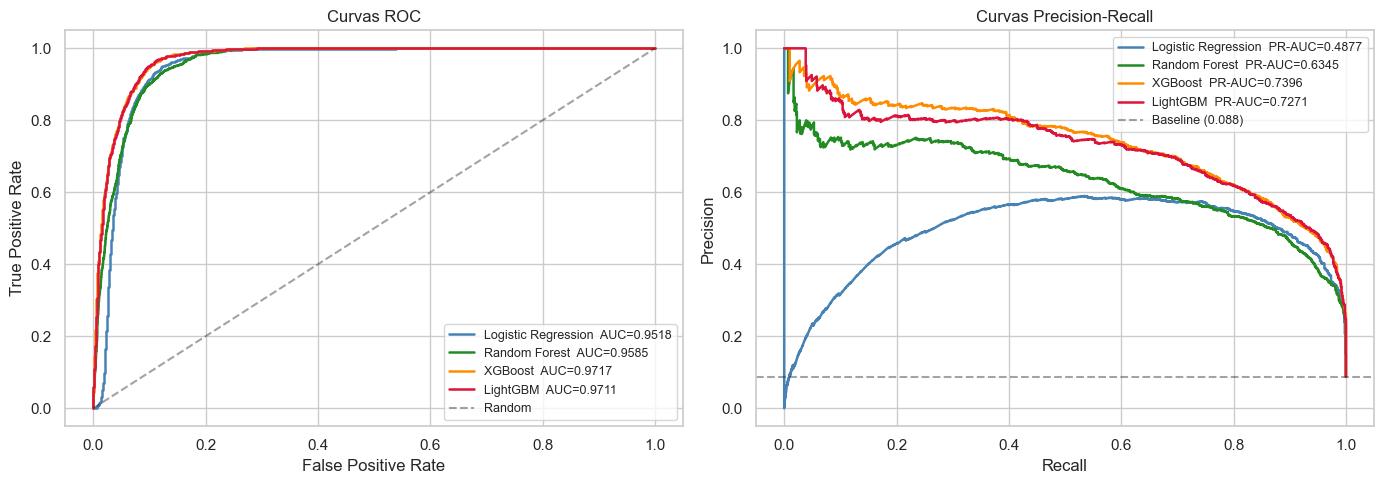

In [15]:
colors = {
    'lr':   'steelblue',
    'rf':   'forestgreen',
    'xgb':  'darkorange',
    'lgbm': 'crimson',
}

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 5))

# ── ROC ──────────────────────────────────────────────────────────────────────
for key, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax_roc.plot(fpr, tpr, label=f"{res['model']}  AUC={res['roc_auc']:.4f}", color=colors[key], lw=1.8)
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('Curvas ROC')
ax_roc.legend(loc='lower right', fontsize=9)

# ── PR ───────────────────────────────────────────────────────────────────────
for key, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    ax_pr.plot(rec, prec, label=f"{res['model']}  PR-AUC={res['pr_auc']:.4f}", color=colors[key], lw=1.8)
baseline = y_test.mean()
ax_pr.axhline(baseline, color='k', linestyle='--', alpha=0.4, label=f'Baseline ({baseline:.3f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Curvas Precision-Recall')
ax_pr.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('data/warehouse/curvas_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Análisis del modelo ganador

Matrices de confusión en el umbral óptimo (máximo F1 en curva PR).

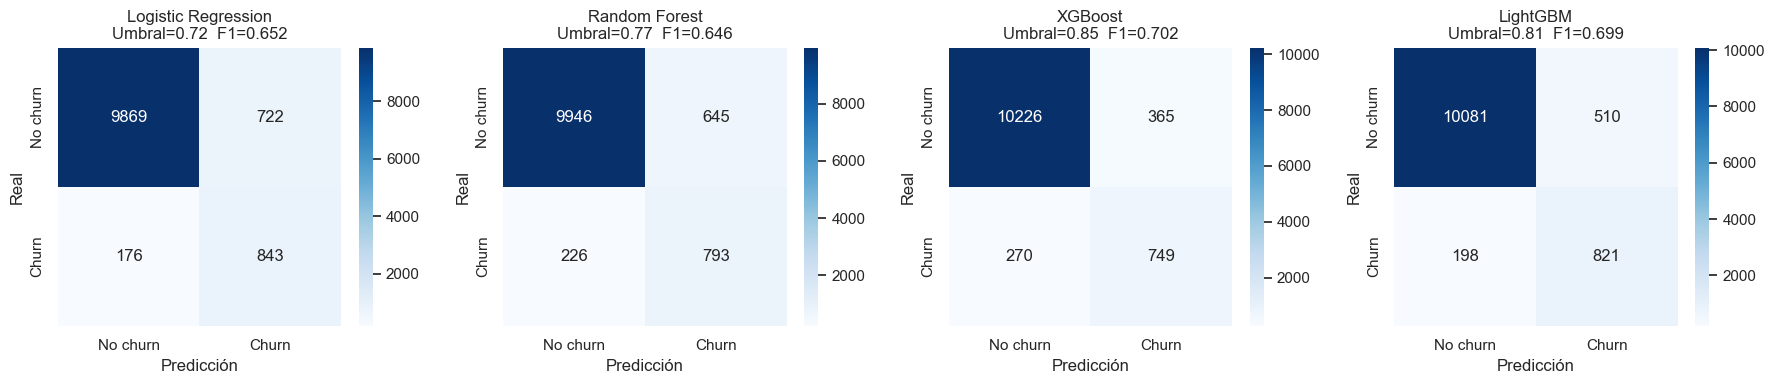

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (key, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No churn', 'Churn'],
                yticklabels=['No churn', 'Churn'])
    ax.set_title(f"{res['model']}\nUmbral={res['opt_threshold']:.2f}  F1={res['f1_opt']:.3f}")
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

In [17]:
best_key = max(results, key=lambda k: results[k]['roc_auc'])
best      = results[best_key]

print(f"Modelo ganador: {best['model']}")
print(f"ROC-AUC: {best['roc_auc']:.4f}  |  PR-AUC: {best['pr_auc']:.4f}")
print(f"Umbral óptimo: {best['opt_threshold']:.3f}")
print()
print(classification_report(y_test, best['y_pred'], target_names=['No churn', 'Churn']))

Modelo ganador: XGBoost
ROC-AUC: 0.9717  |  PR-AUC: 0.7396
Umbral óptimo: 0.851

              precision    recall  f1-score   support

    No churn       0.97      0.97      0.97     10591
       Churn       0.67      0.74      0.70      1019

    accuracy                           0.95     11610
   macro avg       0.82      0.85      0.84     11610
weighted avg       0.95      0.95      0.95     11610



## 11. Predicciones sobre scoring.csv

Aplicamos el modelo ganador al conjunto de scoring y guardamos las predicciones.

In [18]:
scoring = pd.read_csv("data/warehouse/scoring.csv")
print(f"Scoring shape: {scoring.shape}")
scoring.head(3)

Scoring shape: (10000, 23)


,code,pvp,margen_relativo,margen_eur_negativo,coste_venta_no_impuestos,forma_pago,dias_desde_compra,en_garantia,mantenimiento_gratuito,seguro_bateria_largo_plazo,...,revisiones,edad,genero,renta_media_estimada,renta_desconocida,status_social,modelo,equipamiento,es_electrico,kw
0,SYN009876,32916.0,0.253105,0,0.0,Contado,-9,1,0,1,...,0,42,M,28175.0,0,G,I,Mid-High,0,106.0
1,SYN004421,30388.0,0.203704,0,1482.0,Financiera Marca,-40,1,0,0,...,0,22,F,37630.0,0,A,I,High,0,106.0
2,SYN008347,14814.0,0.014955,0,1635.0,Financiera Marca,-9,1,0,0,...,0,48,M,21332.0,0,I,I,High,0,117.0


In [19]:
X_scoring = scoring.drop(columns=['code'])

# Si el modelo ganador es LightGBM necesita preprocessing especial
if best_key == 'lgbm':
    X_scoring_proc = prep_lgbm(X_scoring)
    scoring_proba  = lgbm_model.predict_proba(X_scoring_proc)[:, 1]
else:
    model_map     = {'lr': lr_pipeline, 'rf': rf_pipeline, 'xgb': xgb_pipeline}
    scoring_proba = model_map[best_key].predict_proba(X_scoring)[:, 1]

scoring_pred = (scoring_proba >= best['opt_threshold']).astype(int)

print(f"Registros en scoring: {len(scoring):,}")
print(f"Churn predicho: {scoring_pred.sum():,}  ({scoring_pred.mean():.1%})")

Registros en scoring: 10,000
Churn predicho: 0  (0.0%)


In [25]:
output = scoring[['code']].copy()
output['churn_proba'] = scoring_proba.round(4)
output['churn_pred'] = scoring_pred

out_path = "data/warehouse/predictions.csv"
output.to_csv(out_path, index=False)
print(f"Predicciones guardadas en: {out_path}")
print(output[output['churn_pred'] == 1])
output.head(10)


Predicciones guardadas en: data/warehouse/predictions.csv
Empty DataFrame
Columns: [code, churn_proba, churn_pred]
Index: []


,code,churn_proba,churn_pred
0,SYN009876,0.0000,0
1,SYN004421,0.0000,0
2,SYN008347,0.0001,0
3,SYN001098,0.0000,0
4,SYN002408,0.0001,0
5,SYN009885,0.0001,0
6,SYN006662,0.0001,0
7,SYN003182,0.0000,0
8,SYN006264,0.0001,0
9,SYN009066,0.0000,0


### Estructura de las predicciones

Sin etiqueta real, usamos `churn_proba` y `churn_pred` para entender cómo se distribuyen las predicciones sobre la población de scoring.

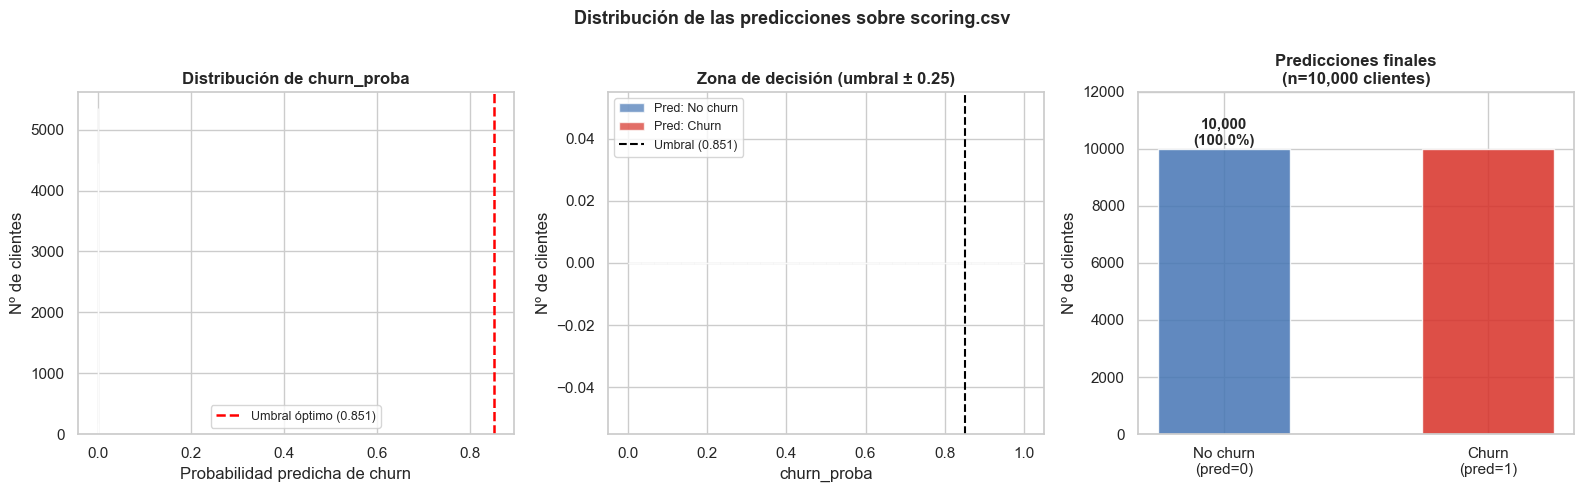

In [21]:
# ── Distribución de probabilidades predichas ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Histograma de churn_proba
ax = axes[0]
ax.hist(output['churn_proba'], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(best['opt_threshold'], color='red', linestyle='--', linewidth=1.8,
           label=f'Umbral óptimo ({best["opt_threshold"]:.3f})')
ax.set_xlabel('Probabilidad predicha de churn')
ax.set_ylabel('Nº de clientes')
ax.set_title('Distribución de churn_proba', fontweight='bold')
ax.legend(fontsize=9)

# 2. Zoom en la zona de decisión (umbral ± 0.2)
ax = axes[1]
t = best['opt_threshold']
zona = output[(output['churn_proba'] >= max(0, t - 0.25)) &
              (output['churn_proba'] <= min(1, t + 0.25))]
ax.hist(zona.loc[zona['churn_pred']==0, 'churn_proba'],
        bins=30, color='#4575b4', alpha=0.7, label='Pred: No churn', edgecolor='white')
ax.hist(zona.loc[zona['churn_pred']==1, 'churn_proba'],
        bins=30, color='#d73027', alpha=0.7, label='Pred: Churn',    edgecolor='white')
ax.axvline(t, color='black', linestyle='--', linewidth=1.5, label=f'Umbral ({t:.3f})')
ax.set_xlabel('churn_proba'); ax.set_ylabel('Nº de clientes')
ax.set_title(f'Zona de decisión (umbral ± 0.25)', fontweight='bold')
ax.legend(fontsize=9)

# 3. Conteo predicho churn vs no churn
ax = axes[2]
counts = output['churn_pred'].value_counts().sort_index()
labels = ['No churn\n(pred=0)', 'Churn\n(pred=1)']
colors_pie = ['#4575b4', '#d73027']
bars = ax.bar(labels, counts.values, color=colors_pie, alpha=0.85, edgecolor='white', width=0.5)
for bar, count in zip(bars, counts.values):
    pct = count / len(output) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Nº de clientes')
ax.set_title(f'Predicciones finales\n(n={len(output):,} clientes)', fontweight='bold')
ax.set_ylim(0, counts.max() * 1.2)

plt.suptitle('Distribución de las predicciones sobre scoring.csv', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

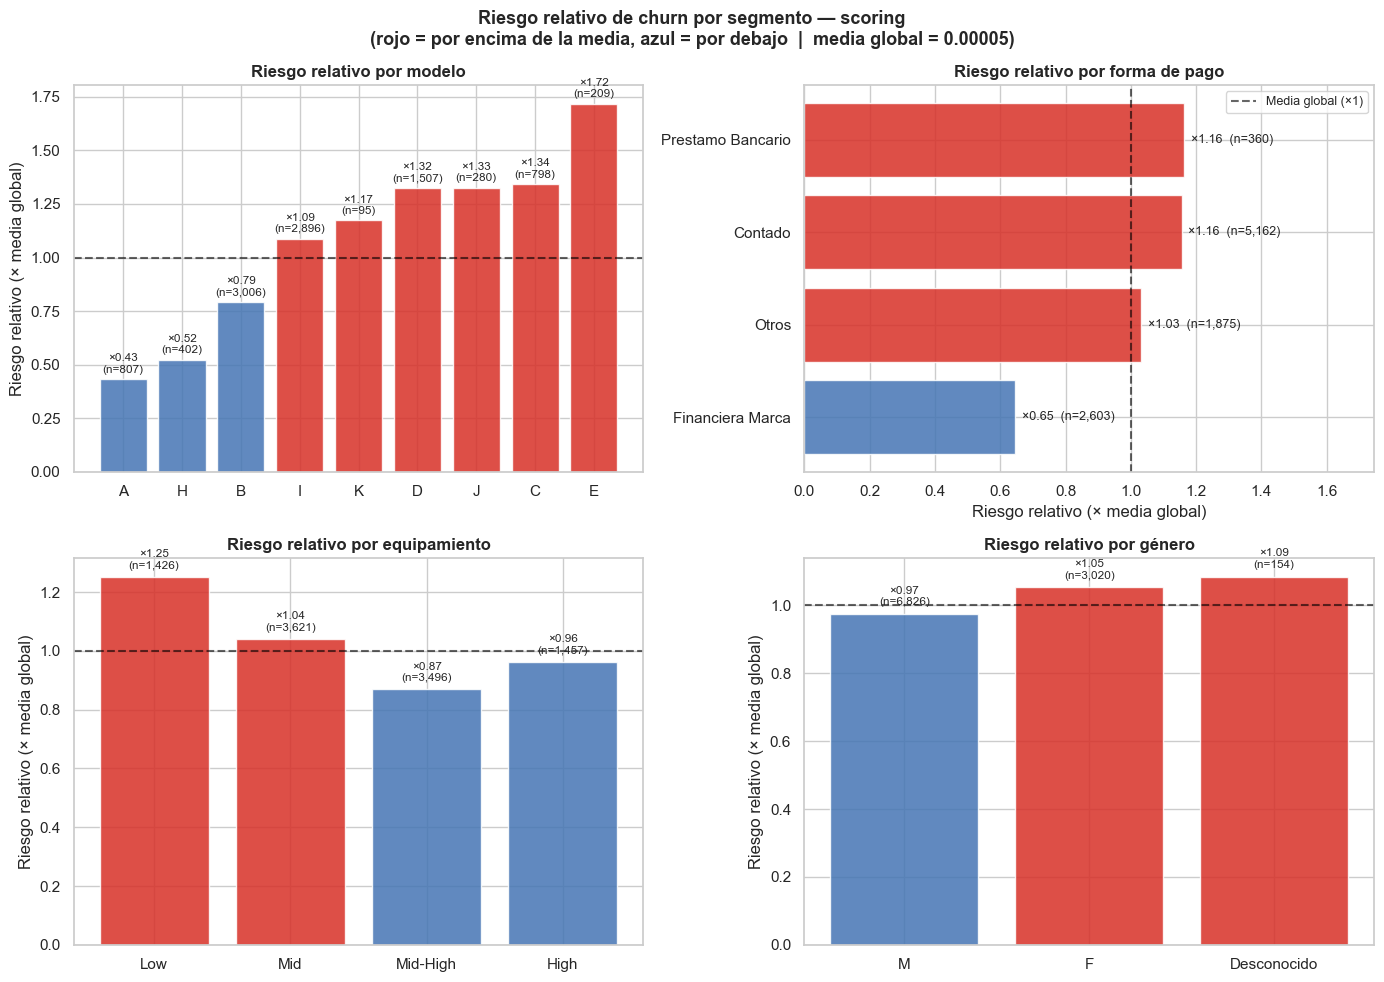

In [22]:
# ── Riesgo relativo de churn por segmento (scoring) ──────────────────────────                                                                                                                                                                                                                                
# churn_proba absoluta es ~0 para todos (clientes sin 400 días aún).
# El riesgo RELATIVO (grupo / media global) sí revela la estructura del modelo.                                                                                                                                                                                                                                
                                                                                                                                                                                                                                                                                                            
sc = output.merge(scoring.drop(columns=['code']), left_index=True, right_index=True)

global_mean = sc['churn_proba'].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, title) in zip(axes.flat, [
    ('modelo',       'Riesgo relativo por modelo'),
    ('forma_pago',   'Riesgo relativo por forma de pago'),
    ('equipamiento', 'Riesgo relativo por equipamiento'),
    ('genero',       'Riesgo relativo por género'),
]):
    if col == 'equipamiento':
        order = ['Low', 'Mid', 'Mid-High', 'High']
        cr  = sc.groupby(col)['churn_proba'].mean().reindex(order)
        cnt = sc.groupby(col)['churn_pred'].agg(['sum', 'count']).reindex(order)
    else:
        cr  = sc.groupby(col)['churn_proba'].mean().sort_values()
        cnt = sc.groupby(col)['churn_pred'].agg(['sum', 'count']).reindex(cr.index)

    rr = cr / global_mean  # riesgo relativo (1.0 = media global)
    colors_bar = ['#d73027' if v > 1 else '#4575b4' for v in rr.values]

    if col == 'forma_pago':
        bars = ax.barh(rr.index, rr.values, color=colors_bar, alpha=0.85, edgecolor='white')
        ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.6, label='Media global (×1)')
        for bar, (idx, row) in zip(bars, cnt.iterrows()):
            ax.text(bar.get_width() + 0.02,
                    bar.get_y() + bar.get_height() / 2,
                    f'×{bar.get_width():.2f}  (n={int(row["count"]):,})',
                    va='center', fontsize=9)
        ax.set_xlim(0, rr.max() * 1.5)
        ax.set_xlabel('Riesgo relativo (× media global)')
        ax.legend(fontsize=9)
    else:
        bars = ax.bar(rr.index, rr.values, color=colors_bar, alpha=0.85, edgecolor='white')
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
        for bar, (idx, row) in zip(bars, cnt.iterrows()):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02,
                    f'×{bar.get_height():.2f}\n(n={int(row["count"]):,})',
                    ha='center', va='bottom', fontsize=8.5)
        ax.set_ylabel('Riesgo relativo (× media global)')

    ax.set_title(title, fontweight='bold')

plt.suptitle(
    f'Riesgo relativo de churn por segmento — scoring\n'
    f'(rojo = por encima de la media, azul = por debajo  |  media global = {global_mean:.5f})',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/wm/9zl_s0kn46n56k_vcfy7q0cc0000gn/T/ipykernel_13664/3464931945.py:35: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


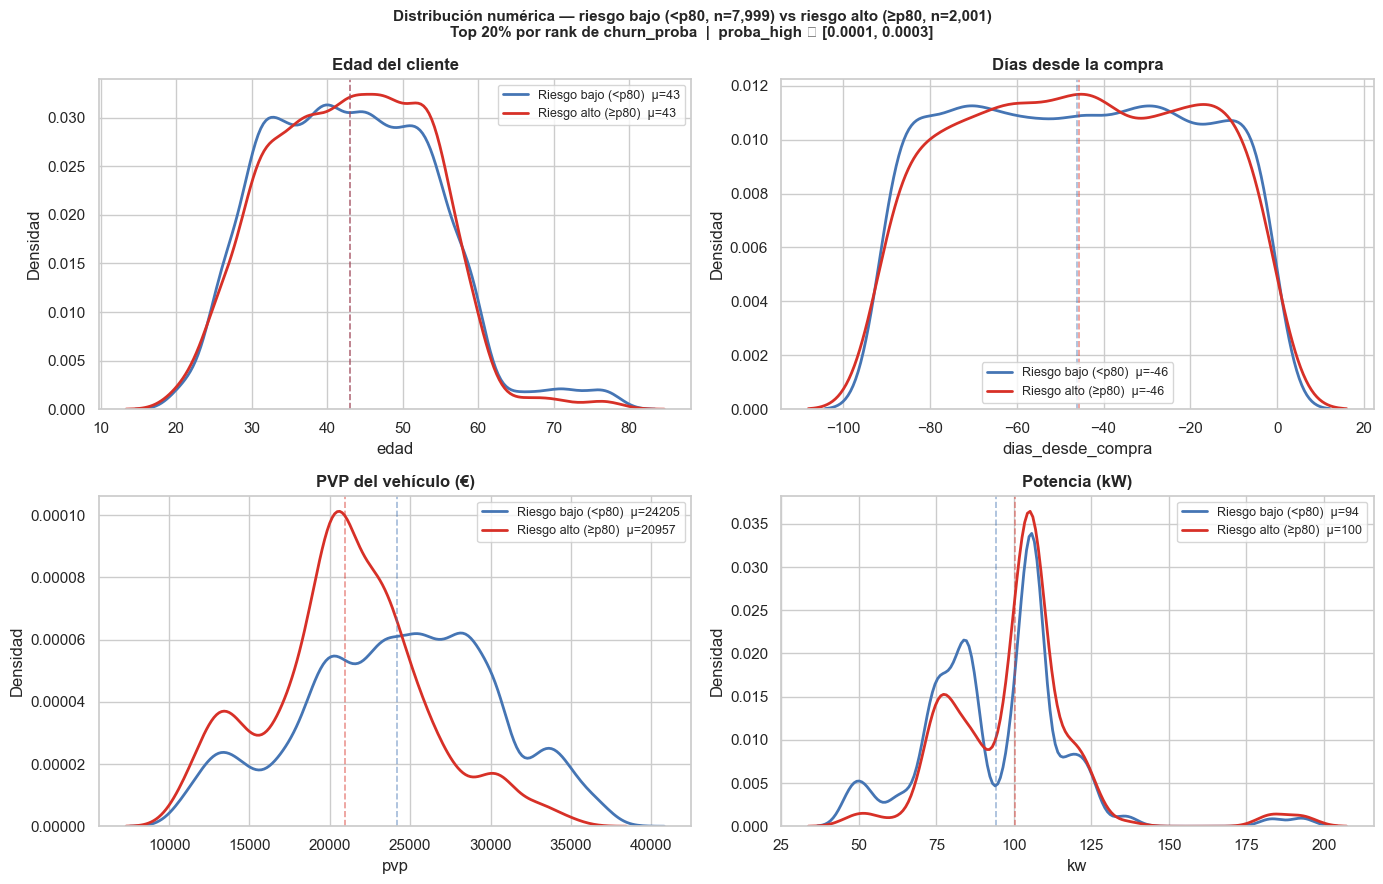

In [23]:
# ── Distribución numérica por nivel de riesgo predicho ───────────────────────
# Split por rank percentil de churn_proba: top 20% vs bottom 80%
# (rank garantiza grupos no vacíos aunque haya muchos empates en 0)

sc['proba_rank'] = sc['churn_proba'].rank(pct=True, method='first')
risk_high = sc[sc['proba_rank'] >= 0.80]   # top 20% de mayor riesgo relativo
risk_low  = sc[sc['proba_rank'] <  0.80]   # bottom 80%

num_plot = {
    'edad':              'Edad del cliente',
    'dias_desde_compra': 'Días desde la compra',
    'pvp':               'PVP del vehículo (€)',
    'kw':                'Potencia (kW)',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (col, title) in zip(axes.flat, num_plot.items()):
    sns.kdeplot(data=risk_low,  x=col, ax=ax, color='#4575b4', linewidth=2,
                label=f'Riesgo bajo (<p80)  μ={risk_low[col].mean():.0f}',
                warn_singular=False)
    sns.kdeplot(data=risk_high, x=col, ax=ax, color='#d73027', linewidth=2,
                label=f'Riesgo alto (≥p80)  μ={risk_high[col].mean():.0f}',
                warn_singular=False)
    ax.axvline(risk_low[col].mean(),  color='#4575b4', linestyle='--', alpha=0.5, linewidth=1.2)
    ax.axvline(risk_high[col].mean(), color='#d73027', linestyle='--', alpha=0.5, linewidth=1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.suptitle(
    f'Distribución numérica — riesgo bajo (<p80, n={len(risk_low):,}) vs riesgo alto (≥p80, n={len(risk_high):,})\n'
    f'Top 20% por rank de churn_proba  |  proba_high ∈ [{risk_high["churn_proba"].min():.4f}, {risk_high["churn_proba"].max():.4f}]',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()